In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading HepG2 Dataset

In [29]:
hepg2_exp = pd.read_csv("dataset/GSM3718064_HepG2_exp.txt", sep="\t")

In [30]:
display(hepg2_exp.head())

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant
0,XLOC_000001,XLOC_000001,OR4F5,chr1:69090-70008,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no
1,XLOC_000002,XLOC_000002,"LOC100132062,LOC100133331",chr1:323891-328581,hepg2_hr2,hepg2_hr3,NOTEST,0.047392,0.034159,-0.472389,0.000000,1.00000,1.000000,no
2,XLOC_000003,XLOC_000003,OR4F29,chr1:367658-368597,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no
3,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,hepg2_hr3,OK,2.468570,2.805800,0.184736,0.455074,0.63585,0.999565,no
4,XLOC_000005,XLOC_000005,-,chr1:840263-843900,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no


In [5]:
hepg2_exp.shape

(30032, 14)

## Splitting the locus into chromosome name and position

In [6]:
hepg2_exp[["locus_chr", "locus_pos"]] = hepg2_exp["locus"].str.split(':', expand=True)
hepg2_exp.head()

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,locus_chr,locus_pos
0,XLOC_000001,XLOC_000001,OR4F5,chr1:69090-70008,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,69090-70008
1,XLOC_000002,XLOC_000002,"LOC100132062,LOC100133331",chr1:323891-328581,hepg2_hr2,hepg2_hr3,NOTEST,0.047392,0.034159,-0.472389,0.000000,1.00000,1.000000,no,chr1,323891-328581
2,XLOC_000003,XLOC_000003,OR4F29,chr1:367658-368597,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,367658-368597
3,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,hepg2_hr3,OK,2.468570,2.805800,0.184736,0.455074,0.63585,0.999565,no,chr1,761585-794889
4,XLOC_000005,XLOC_000005,-,chr1:840263-843900,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,840263-843900


In [7]:
hepg2_exp[["locus_start", "locus_end"]] = hepg2_exp["locus_pos"].str.split('-', expand=True)
hepg2_exp.head()

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,locus_chr,locus_pos,locus_start,locus_end
0,XLOC_000001,XLOC_000001,OR4F5,chr1:69090-70008,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,69090-70008,69090,70008
1,XLOC_000002,XLOC_000002,"LOC100132062,LOC100133331",chr1:323891-328581,hepg2_hr2,hepg2_hr3,NOTEST,0.047392,0.034159,-0.472389,0.000000,1.00000,1.000000,no,chr1,323891-328581,323891,328581
2,XLOC_000003,XLOC_000003,OR4F29,chr1:367658-368597,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,367658-368597,367658,368597
3,XLOC_000004,XLOC_000004,LOC643837,chr1:761585-794889,hepg2_hr2,hepg2_hr3,OK,2.468570,2.805800,0.184736,0.455074,0.63585,0.999565,no,chr1,761585-794889,761585,794889
4,XLOC_000005,XLOC_000005,-,chr1:840263-843900,hepg2_hr2,hepg2_hr3,NOTEST,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,no,chr1,840263-843900,840263,843900


## Converting the locus_start and locus_end column into appropriate data types

In [8]:
hepg2_exp.dtypes

test_id               object
gene_id               object
gene                  object
locus                 object
sample_1              object
sample_2              object
status                object
value_1              float64
value_2              float64
log2(fold_change)    float64
test_stat            float64
p_value              float64
q_value              float64
significant           object
locus_chr             object
locus_pos             object
locus_start           object
locus_end             object
dtype: object

In [9]:
hepg2_exp = hepg2_exp.astype({'locus_start': 'float64', 'locus_end': 'float64'})
hepg2_exp.dtypes

test_id               object
gene_id               object
gene                  object
locus                 object
sample_1              object
sample_2              object
status                object
value_1              float64
value_2              float64
log2(fold_change)    float64
test_stat            float64
p_value              float64
q_value              float64
significant           object
locus_chr             object
locus_pos             object
locus_start          float64
locus_end            float64
dtype: object

In [25]:
# Find the unique chromosome name
hepg2_exp = pd.DataFrame(hepg2_exp["locus_chr"].unique(), columns=["locus_chr"])
hepg2_exp.to_csv("dataset/results/HepG2_Chromosome.csv", index=False, header=False)
hepg2_exp.head()

,locus_chr
0,chr1
1,chr10
2,chr11
3,chr12
4,chr13


In [11]:
hepg2_exp.groupby("significant").count()

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,locus_chr,locus_pos,locus_start,locus_end
significant,,,,,,,,,,,,,,,,,
no,30032,30032,30032,30032,30032,30032,30032,30032,30032,30032,29910,30032,30032,30032,30032,30032,30032


In [12]:
hepg2_exp.groupby("status").count()

,test_id,gene_id,gene,locus,sample_1,sample_2,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant,locus_chr,locus_pos,locus_start,locus_end
status,,,,,,,,,,,,,,,,,
FAIL,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
HIDATA,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
NOTEST,16092,16092,16092,16092,16092,16092,16092,16092,16092,16092,16092,16092,16092,16092,16092,16092,16092
OK,13934,13934,13934,13934,13934,13934,13934,13934,13934,13812,13934,13934,13934,13934,13934,13934,13934


## Checking the p_value distribution

In [13]:
# Check the p-value distribution
hepg2_exp["p_value"].describe()

count    30032.000000
mean         0.864266
std          0.219135
min          0.000050
25%          0.797000
50%          1.000000
75%          1.000000
max          1.000000
Name: p_value, dtype: float64

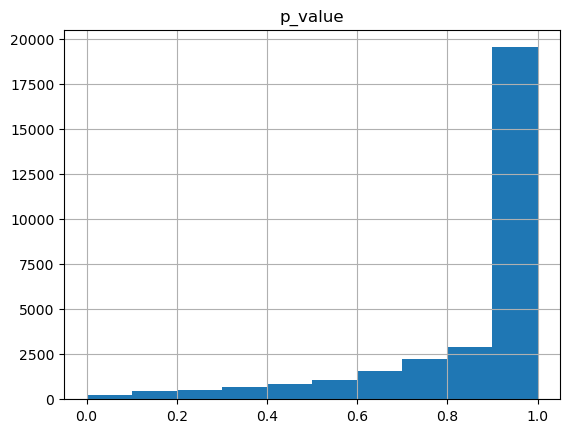

In [14]:
ax = hepg2_exp.hist(column=["p_value"])

In [20]:
hepg2_exp.groupby(['p_value'])['p_value'].count().to_csv("dataset/results/p_value.csv")

In [22]:
hepg2_exp.groupby(['p_value'])['p_value'].count().sort_values(ascending=False)

p_value
1.00000    16098
0.05645       15
0.90195        8
0.94150        7
0.89740        7
           ...  
0.59460        1
0.59450        1
0.59445        1
0.59440        1
0.71565        1
Name: p_value, Length: 8643, dtype: int64